# Segment Level Results

In [1]:
files = {
    "0_10%": "../RESULTS/SEGMENTS_0_10%.csv",
    "10K_5%": "../RESULTS/SEGMENTS_10K_5%.csv",
    "10K_10%": "../RESULTS/SEGMENTS_10K_10%.csv",
}

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


files = {
    "0_10": "../RESULTS/SEGMENTS_0_10%.csv",
    "10K_5": "../RESULTS/SEGMENTS_10K_5%.csv",
    "10K_10": "../RESULTS/SEGMENTS_10K_10%.csv",
}


dfs = []

for config, file in files.items():
    df = pd.read_csv(file)
    df["windows_percent"] = config
    dfs.append(df)


all_df = pd.concat(dfs, ignore_index=True)

print(all_df.shape)

(24588, 22)


In [57]:
all_df.columns

Index(['config', 'C', 'gamma', 'percentile', 'patient', 'record', 'n_windows',
       'n_seizure_windows', 'record_length', 'threshold', 'k', 'roc_auc', 'ap',
       'seg_accuracy', 'seg_specificity', 'seg_sensitivity', 'seg_precision',
       'seg_f1', 'tp', 'fp', 'fn', 'windows_percent'],
      dtype='object')

## 1. Summary table across all configs

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================
# Pooled segment-level table
# ==========================

segment_results = (
    all_df
    .groupby(
        [
            "windows_percent",
            "config",
            "C",
            "gamma",
            "percentile"
        ]
    )
    .agg(
        # discrimination
        AUC=("roc_auc", "mean"),
        AUC_std=("roc_auc", "std"),
        AP=("ap", "mean"),

        # pooled counts
        TP=("tp", "sum"),
        FP=("fp", "sum"),
        FN=("fn", "sum"),

        # segment metrics
        specificity=("seg_specificity", "mean")
    )
    .reset_index()
)


# pooled sensitivity
segment_results["segment_sensitivity"] = (
    segment_results["TP"] /
    (segment_results["TP"] + segment_results["FN"])
)


# pooled precision
segment_results["segment_precision"] = (
    segment_results["TP"] /
    (segment_results["TP"] + segment_results["FP"])
)


segment_results

,windows_percent,config,C,gamma,percentile,AUC,AUC_std,AP,TP,FP,FN,specificity,segment_sensitivity,segment_precision
0,0_10,A10,0.1,scale,10,0.880656,0.135847,0.369443,2417,137079,2052,0.944046,0.540837,0.017327
1,0_10,B10,0.1,0.01,10,0.872530,0.139399,0.344784,2029,114264,2440,0.957463,0.454017,0.017447
2,0_10,C10,0.1,0.001,10,0.886720,0.134840,0.370462,3144,240243,1325,0.878772,0.703513,0.012918
3,0_10,D10,0.1,0.0001,10,0.872114,0.146939,0.344225,3118,384003,1351,0.828869,0.697695,0.008054
4,0_10,E10,1.0,scale,10,0.877488,0.141475,0.395677,1428,23817,3041,0.987730,0.319535,0.056566
5,0_10,F10,1.0,0.01,10,0.867188,0.147321,0.373733,913,12955,3556,0.993694,0.204296,0.065835
6,0_10,G10,1.0,0.001,10,0.887701,0.125569,0.383838,2711,127795,1758,0.932804,0.606623,0.020773
7,0_10,H10,1.0,0.0001,10,0.886381,0.133942,0.367324,3180,253731,1289,0.872804,0.711569,0.012378
8,0_10,I10,10.0,scale,10,0.868805,0.146183,0.401066,1067,8750,3402,0.995788,0.238756,0.108689
9,0_10,J10,10.0,0.01,10,0.858107,0.151052,0.377197,716,5475,3753,0.997651,0.160215,0.115652


> Across all configurations and evaluated sampling strategies, ROC-AUC remained within a narrow range (X-Y). The limited variation across C, $\gamma$, percentile and sampling strategy indicates that the spectral GC feature representation consistently capture information that separates ictal and interictal windows in general.

## 2. Ranges across grid

In [66]:
segment_summary = (
    segment_results
    .groupby("windows_percent")
    .agg(
        AUC_min=("AUC","min"),
        AUC_max=("AUC","max"),

        AP_min=("AP","min"),
        AP_max=("AP","max"),

        sensitivity_min=("segment_sensitivity","min"),
        sensitivity_max=("segment_sensitivity","max"),

        specificity_min=("specificity","min"),
        specificity_max=("specificity","max"),

        precision_min=("segment_precision","min"),
        precision_max=("segment_precision","max")
    )
    .reset_index()
)


segment_summary

,windows_percent,AUC_min,AUC_max,AP_min,AP_max,sensitivity_min,sensitivity_max,specificity_min,specificity_max,precision_min,precision_max
0,0_10,0.858107,0.887701,0.344225,0.401066,0.160215,0.711569,0.828869,0.997651,0.008054,0.115652
1,10K_10,0.855042,0.879031,0.353319,0.405900,0.142537,0.713582,0.823810,0.998499,0.013166,0.257062
2,10K_5,0.853207,0.876339,0.330399,0.371472,0.177668,0.712240,0.809018,0.995495,0.010571,0.114376


## 3. AUC Distribution

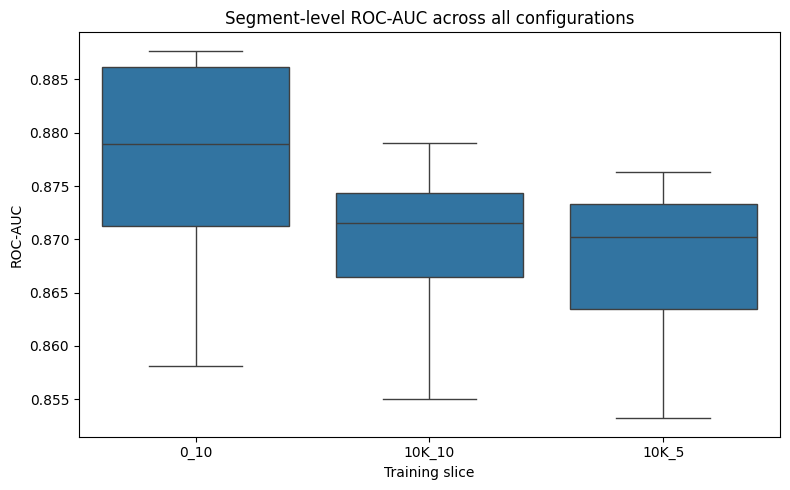

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=segment_results,
    x="windows_percent",
    y="AUC"
)

plt.xlabel("Training slice")
plt.ylabel("ROC-AUC")

plt.title(
    "Segment-level ROC-AUC across all configurations"
)

plt.tight_layout()
plt.show()

## 4. C x gamma heatmap

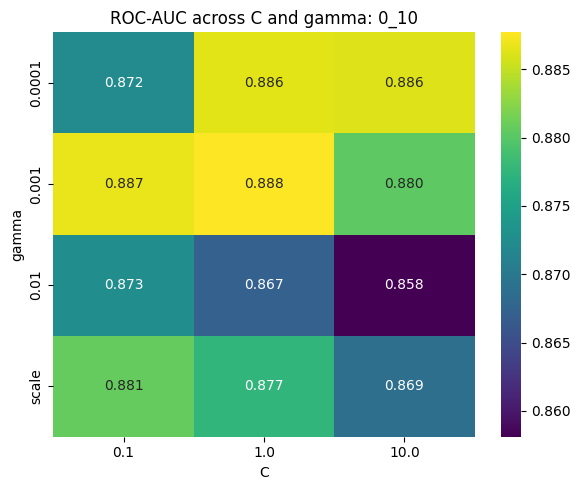

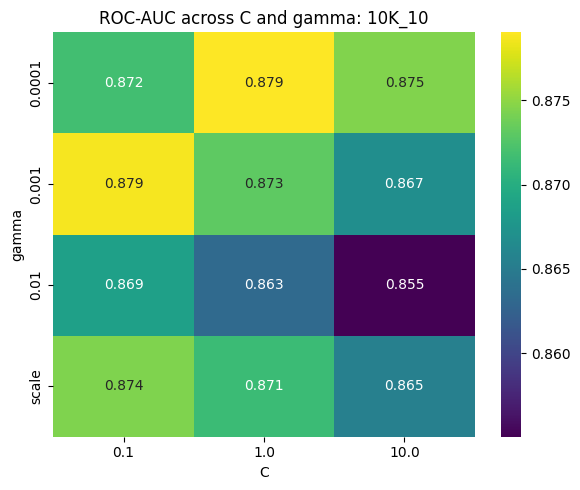

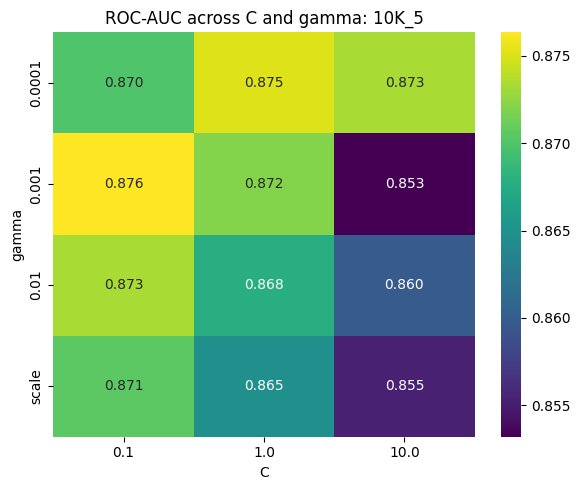

In [70]:
for arm in segment_results["windows_percent"].unique():

    temp = segment_results[
        segment_results["windows_percent"] == arm
    ]

    heat = (
        temp
        .groupby(["C","gamma"])["AUC"]
        .mean()
        .reset_index()
    )

    heat = heat.pivot(
        index="gamma",
        columns="C",
        values="AUC"
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        heat,
        annot=True,
        fmt=".3f",
        cmap="viridis"
    )

    plt.title(
        f"ROC-AUC across C and gamma: {arm}"
    )

    plt.xlabel("C")
    plt.ylabel("gamma")

    plt.tight_layout()
    plt.show()

> The similarity in AUC values across the C and γ search space suggests that the classifier performance was relatively insensitive to the evaluated SVM regularisation and kernel parameters. Which means that the model does not require a narrowly tuned parameter combination to achieve comparable separation.

## 5. Average Precision Distribution

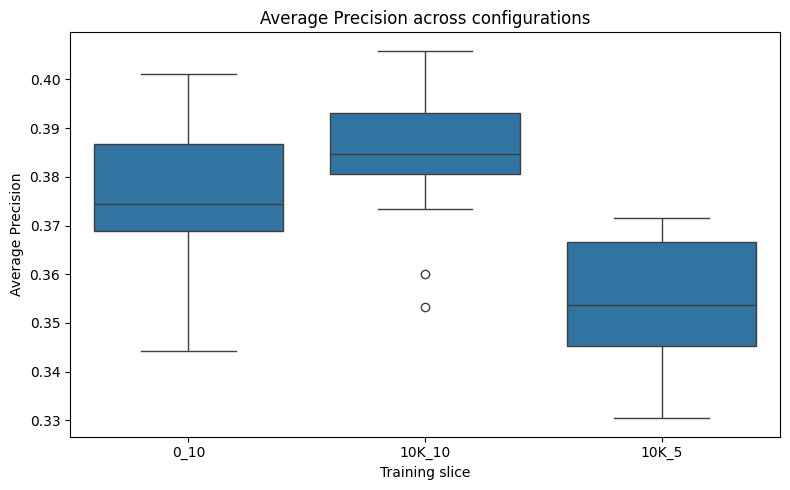

In [69]:
plt.figure(figsize=(8,5))


sns.boxplot(
    data=segment_results,
    x="windows_percent",
    y="AP"
)


plt.xlabel("Training slice")
plt.ylabel("Average Precision")


plt.title(
    "Average Precision across configurations"
)


plt.tight_layout()
plt.show()